In [3]:
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.express as px
import yfinance as yf

# Get Apple's stock data from yahoo finance
stock = yf.Ticker("GC=F")
data = stock.history(period="6mo")
print(data.head())

                                  Open         High          Low        Close  \
Date                                                                            
2025-03-04 00:00:00-05:00  2886.100098  2927.899902  2886.100098  2909.600098   
2025-03-05 00:00:00-05:00  2916.699951  2922.000000  2893.000000  2915.300049   
2025-03-06 00:00:00-05:00  2904.000000  2918.600098  2903.800049  2916.600098   
2025-03-07 00:00:00-05:00  2900.899902  2927.300049  2900.500000  2904.699951   
2025-03-10 00:00:00-04:00  2910.100098  2915.100098  2880.199951  2891.000000   

                           Volume  Dividends  Stock Splits  
Date                                                        
2025-03-04 00:00:00-05:00     885        0.0           0.0  
2025-03-05 00:00:00-05:00     551        0.0           0.0  
2025-03-06 00:00:00-05:00     870        0.0           0.0  
2025-03-07 00:00:00-05:00     531        0.0           0.0  
2025-03-10 00:00:00-04:00      55        0.0           0.0  


In [4]:
# Calculation of momentum
data['momentum'] = data['Close'].pct_change()

# Creating subplots to show momentum and buying/selling markers
figure = make_subplots(rows=2, cols=1)
figure.add_trace(go.Scatter(x=data.index, 
                         y=data['Close'], 
                         name='Close Price'))
figure.add_trace(go.Scatter(x=data.index, 
                         y=data['momentum'], 
                         name='Momentum', 
                         yaxis='y2'))

# Adding the buy and sell signals
figure.add_trace(go.Scatter(x=data.loc[data['momentum'] > 0].index, 
                         y=data.loc[data['momentum'] > 0]['Close'], 
                         mode='markers', name='Buy', 
                         marker=dict(color='green', symbol='triangle-up')))

figure.add_trace(go.Scatter(x=data.loc[data['momentum'] < 0].index, 
                         y=data.loc[data['momentum'] < 0]['Close'], 
                         mode='markers', name='Sell', 
                         marker=dict(color='red', symbol='triangle-down')))

figure.update_layout(
    title='Algorithmic Trading using Momentum Strategy',
    xaxis_title='Date',
    yaxis_title='Price',
    height=800,   # increase height
    width=1200    # increase width
)

figure.update_yaxes(title="Momentum", secondary_y=True)
figure.show()

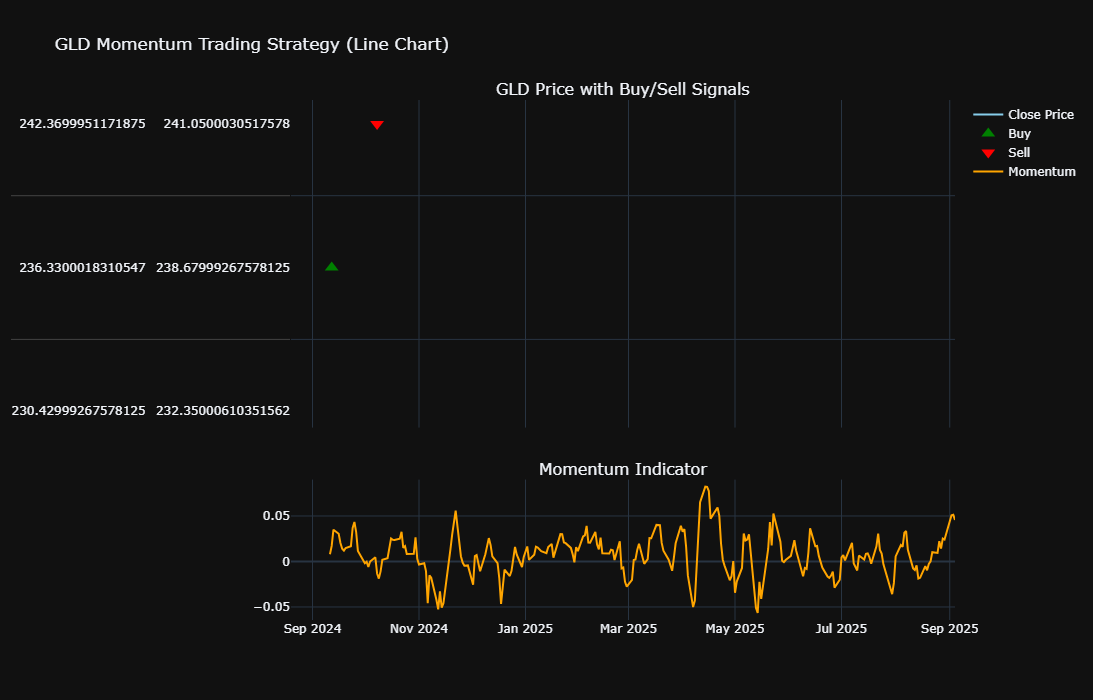

In [12]:
import yfinance as yf
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Parameters
symbol = "GLD"  # Stock symbol (try "GLD" for gold ETF)
period = "1y"    # 1 year of data
momentum_periods = 5
momentum_threshold = 0.01  # 1%

# Download data (use Close only)
df = yf.download(symbol, period=period, progress=False, auto_adjust=True)

# Momentum calculation
df["momentum"] = df["Close"].pct_change(momentum_periods)

# Trading signals
df["signal"] = 0
df.loc[df["momentum"] > momentum_threshold, "signal"] = 1   # Buy
df.loc[df["momentum"] < -momentum_threshold, "signal"] = -1  # Sell

# Create subplots (price + momentum)
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.1,
                    row_heights=[0.7, 0.3],
                    subplot_titles=(f"{symbol} Price with Buy/Sell Signals", "Momentum Indicator"))

# --- Price line chart ---
fig.add_trace(
    go.Scatter(x=df.index, y=df["Close"],
               mode="lines",
               line=dict(color="skyblue", width=2),
               name="Close Price"),
    row=1, col=1
)

# --- Buy signals ---
fig.add_trace(
    go.Scatter(x=df.index[df["signal"] == 1],
               y=df["Close"][df["signal"] == 1],
               mode="markers",
               marker=dict(symbol="triangle-up", color="green", size=12),
               name="Buy"),
    row=1, col=1
)

# --- Sell signals ---
fig.add_trace(
    go.Scatter(x=df.index[df["signal"] == -1],
               y=df["Close"][df["signal"] == -1],
               mode="markers",
               marker=dict(symbol="triangle-down", color="red", size=12),
               name="Sell"),
    row=1, col=1
)

# --- Momentum indicator ---
fig.add_trace(
    go.Scatter(x=df.index, y=df["momentum"],
               mode="lines",
               line=dict(color="orange", width=2),
               name="Momentum"),
    row=2, col=1
)

# Layout
fig.update_layout(
    title=f"{symbol} Momentum Trading Strategy (Line Chart)",
    xaxis_rangeslider_visible=False,
    template="plotly_dark",
    height=700
)

fig.show()
